In [3]:
"""
Notebook 02: Exploratory Data Analysis (EDA)
=============================================

This notebook performs the initial exploratory analysis of the Kepler
Objects of Interest (KOI) cumulative catalog.

Goals:
- Understand dataset structure and dimensions
- Identify the most relevant columns for analysis
- Quantify missing values
- Analyze the target variable distribution
- Generate initial visualizations

Input:  data/raw/kepler_koi_cumulative.csv
Output: data/interim/kepler_koi_relevant.csv

Author: Mersen-cloud
"""

# Standard library
from pathlib import Path

# Third-party
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plotting style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Imports successful ✓")

Imports successful ✓


In [4]:
# Define paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_INTERIM.mkdir(parents=True, exist_ok=True)

INPUT_FILE = DATA_RAW / "kepler_koi_cumulative.csv"

# Load dataset
df = pd.read_csv(INPUT_FILE)
print(f"✓ Dataset loaded from {INPUT_FILE.name}")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✓ Dataset loaded from kepler_koi_cumulative.csv
  Shape: 9564 rows × 155 columns


In [5]:
# Group columns by prefix to understand the structure
column_prefixes = {}
for col in df.columns:
    prefix = col.split('_')[0] if '_' in col else col
    column_prefixes[prefix] = column_prefixes.get(prefix, 0) + 1

print("Column groups by prefix:")
print("=" * 50)
for prefix, count in sorted(column_prefixes.items(), key=lambda x: -x[1]):
    print(f"  {prefix:15s} → {count} columns")

Column groups by prefix:
  koi             → 144 columns
  ra              → 3 columns
  dec             → 3 columns
  sky             → 2 columns
  kepid           → 1 columns
  kepoi           → 1 columns
  kepler          → 1 columns


In [6]:
# Define the relevant subset of columns for analysis
# These represent the most physically meaningful variables for exoplanet analysis

relevant_columns = {
    # Identification
    'kepoi_name': 'KOI name',
    'kepler_name': 'Kepler name (if confirmed)',
    
    # Target variable
    'koi_disposition': 'Disposition (CONFIRMED / CANDIDATE / FALSE POSITIVE)',
    'koi_score': 'Disposition confidence score [0-1]',
    
    # Planet properties
    'koi_period': 'Orbital period [days]',
    'koi_prad': 'Planet radius [Earth radii]',
    'koi_teq': 'Equilibrium temperature [K]',
    'koi_insol': 'Insolation flux [Earth flux]',
    'koi_impact': 'Impact parameter',
    'koi_duration': 'Transit duration [hours]',
    'koi_depth': 'Transit depth [ppm]',
    
    # Stellar properties (host star)
    'koi_steff': 'Stellar effective temperature [K]',
    'koi_slogg': 'Stellar surface gravity [log10(cm/s²)]',
    'koi_srad': 'Stellar radius [Solar radii]',
    'koi_smass': 'Stellar mass [Solar masses]',
    
    # False positive flags
    'koi_fpflag_nt': 'Not transit-like flag',
    'koi_fpflag_ss': 'Stellar eclipse flag',
    'koi_fpflag_co': 'Centroid offset flag',
    'koi_fpflag_ec': 'Ephemeris match flag',
}

# Verify all relevant columns exist in the dataset
missing_cols = [c for c in relevant_columns if c not in df.columns]
if missing_cols:
    print(f"⚠ Missing columns: {missing_cols}")
else:
    print(f"✓ All {len(relevant_columns)} relevant columns are present")

# Create a working DataFrame with only relevant columns
df_rel = df[list(relevant_columns.keys())].copy()
print(f"\n✓ Working DataFrame created: {df_rel.shape[0]} rows × {df_rel.shape[1]} columns")

✓ All 19 relevant columns are present

✓ Working DataFrame created: 9564 rows × 19 columns


In [7]:
# Missing values analysis
missing = df_rel.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_rel) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary['missing_count'] > 0]

print("Missing values per column:")
print("=" * 50)
print(missing_summary)

Missing values per column:
             missing_count  missing_pct
kepler_name           6817      71.2800
koi_score             1510      15.7900
koi_prad               363       3.8000
koi_smass              363       3.8000
koi_srad               363       3.8000
koi_teq                363       3.8000
koi_impact             363       3.8000
koi_depth              363       3.8000
koi_steff              363       3.8000
koi_slogg              363       3.8000
koi_insol              321       3.3600


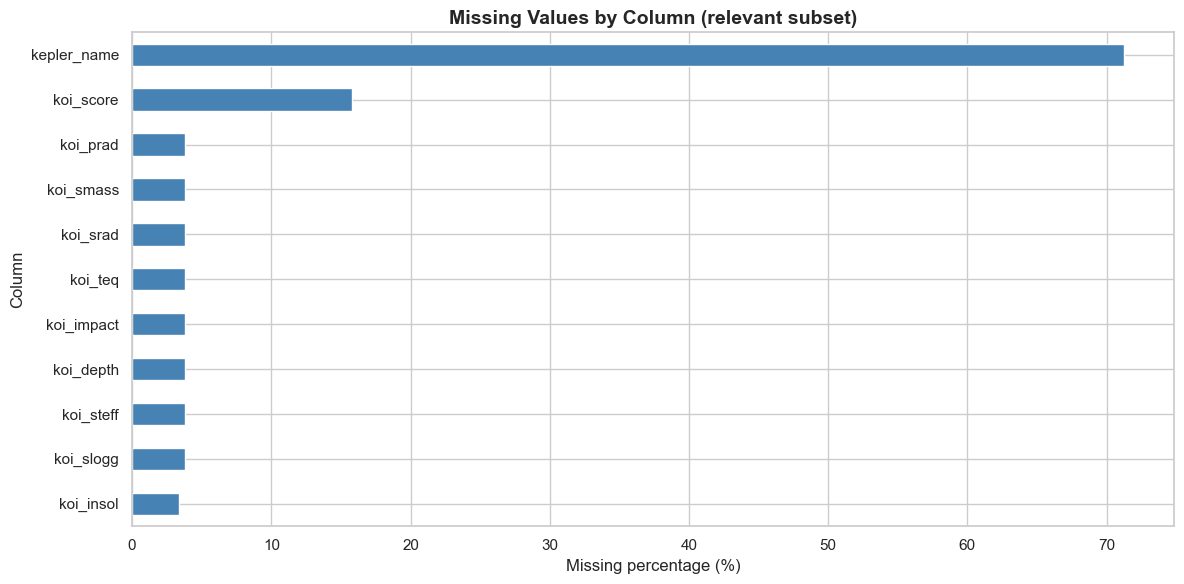

In [8]:
# Visualize missing values pattern
fig, ax = plt.subplots(figsize=(12, 6))
missing_summary['missing_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing percentage (%)')
ax.set_ylabel('Column')
ax.set_title('Missing Values by Column (relevant subset)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# Descriptive statistics for numerical columns
print("Descriptive statistics (numerical columns):")
print("=" * 80)
df_rel.describe()

Descriptive statistics (numerical columns):


,koi_score,koi_period,koi_prad,koi_teq,koi_insol,koi_impact,koi_duration,koi_depth,koi_steff,koi_slogg,koi_srad,koi_smass,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec
count,8054.0000,9564.0000,9201.0000,9201.0000,9243.0000,9201.0000,9564.0000,9201.0000,9201.0000,9201.0000,9201.0000,9201.0000,9564.0000,9564.0000,9564.0000,9564.0000
mean,0.4808,75.6714,102.8918,1085.3858,7745.7370,0.7351,5.6216,23791.3440,5706.8233,4.3102,1.7287,1.0237,0.2086,0.2327,0.1975,0.1200
std,0.4769,1334.7440,3077.6391,856.3512,159204.6652,3.3488,6.4716,82242.6847,796.8579,0.4326,6.1272,0.3494,4.7673,0.4226,0.3981,0.3250
min,0.0000,0.2418,0.0800,25.0000,0.0000,0.0000,0.0520,0.0000,2661.0000,0.0470,0.1090,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,2.7337,1.4000,539.0000,20.1500,0.1970,2.4378,159.9000,5310.0000,4.2180,0.8290,0.8450,0.0000,0.0000,0.0000,0.0000
50%,0.3340,9.7528,2.3900,878.0000,141.6000,0.5370,3.7926,421.1000,5767.0000,4.4380,1.0000,0.9740,0.0000,0.0000,0.0000,0.0000
75%,0.9980,40.7152,14.9300,1379.0000,870.2900,0.8890,6.2765,1473.4000,6112.0000,4.5430,1.3450,1.1010,0.0000,0.0000,0.0000,0.0000
max,1.0000,129995.7784,200346.0000,14667.0000,10947554.5500,100.8060,138.5400,1541400.0000,15896.0000,5.3640,229.9080,3.7350,465.0000,1.0000,1.0000,1.0000


In [10]:
# Target variable analysis
print("=" * 50)
print("TARGET VARIABLE: koi_disposition")
print("=" * 50)

target_counts = df_rel['koi_disposition'].value_counts()
target_pct = df_rel['koi_disposition'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'count': target_counts,
    'percentage': target_pct.round(2)
})
print(target_summary)

TARGET VARIABLE: koi_disposition
                 count  percentage
koi_disposition                   
FALSE POSITIVE    4839     50.6000
CONFIRMED         2747     28.7200
CANDIDATE         1978     20.6800


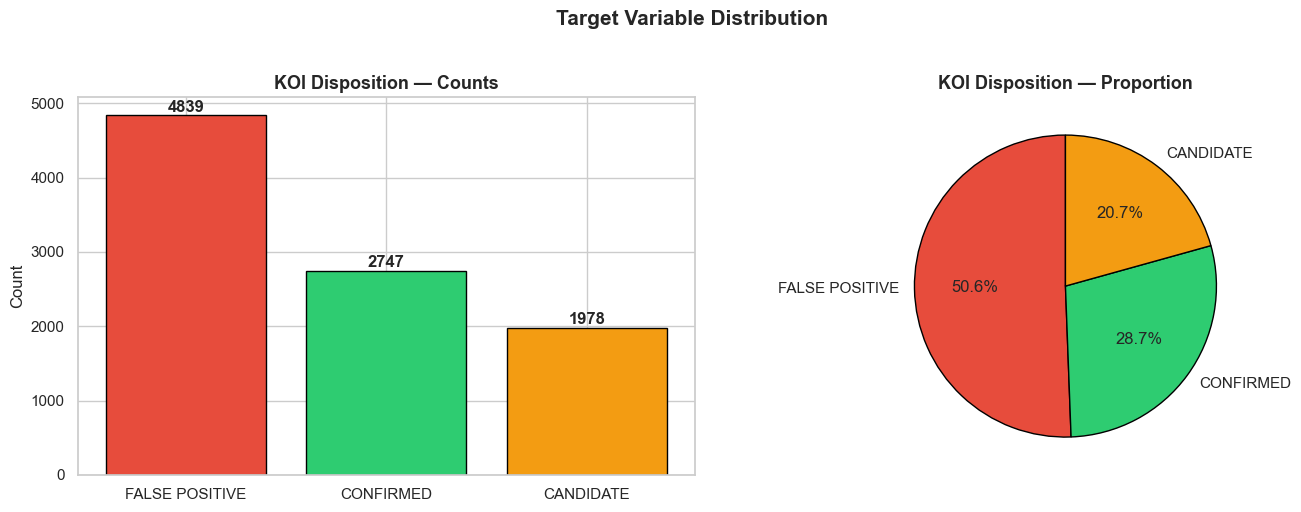

In [11]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = {'CONFIRMED': '#2ecc71', 'CANDIDATE': '#f39c12', 'FALSE POSITIVE': '#e74c3c'}
target_counts = df_rel['koi_disposition'].value_counts()
bar_colors = [colors[x] for x in target_counts.index]

axes[0].bar(target_counts.index, target_counts.values, color=bar_colors, edgecolor='black')
axes[0].set_title('KOI Disposition — Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, colors=bar_colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('KOI Disposition — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

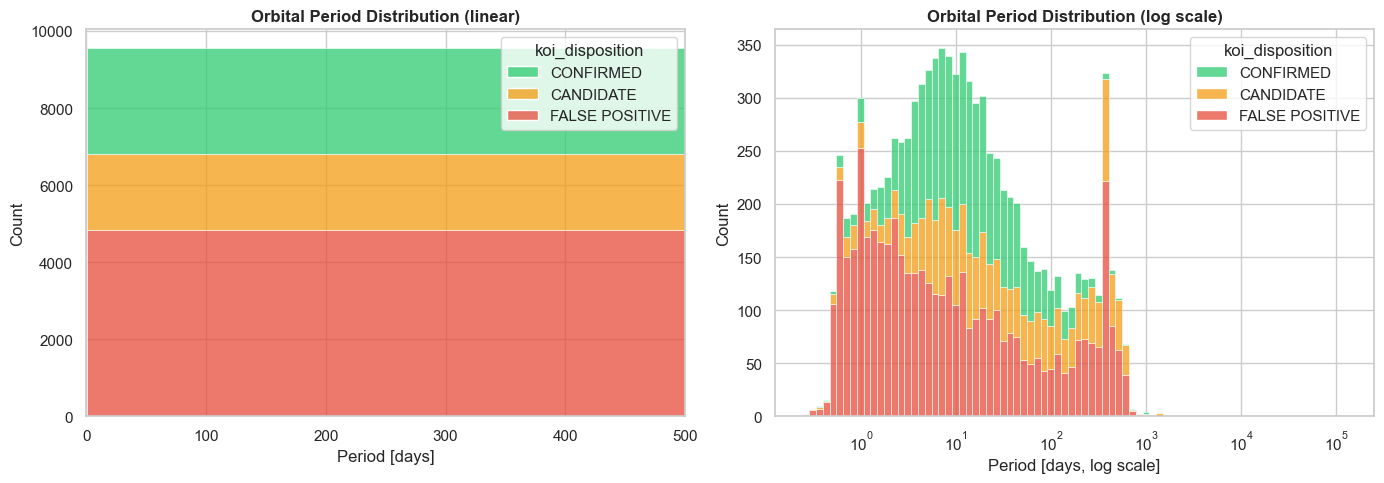


Period range: 0.24 – 129995.78 days
Median period: 9.75 days


In [12]:
# Orbital period distribution by disposition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
sns.histplot(data=df_rel, x='koi_period', hue='koi_disposition',
             palette=colors, bins=80, ax=axes[0], multiple='stack')
axes[0].set_title('Orbital Period Distribution (linear)', fontweight='bold')
axes[0].set_xlabel('Period [days]')
axes[0].set_xlim(0, 500)

# Log scale
sns.histplot(data=df_rel, x='koi_period', hue='koi_disposition',
             palette=colors, bins=80, ax=axes[1], multiple='stack', log_scale=True)
axes[1].set_title('Orbital Period Distribution (log scale)', fontweight='bold')
axes[1].set_xlabel('Period [days, log scale]')

plt.tight_layout()
plt.show()

print(f"\nPeriod range: {df_rel['koi_period'].min():.2f} – {df_rel['koi_period'].max():.2f} days")
print(f"Median period: {df_rel['koi_period'].median():.2f} days")

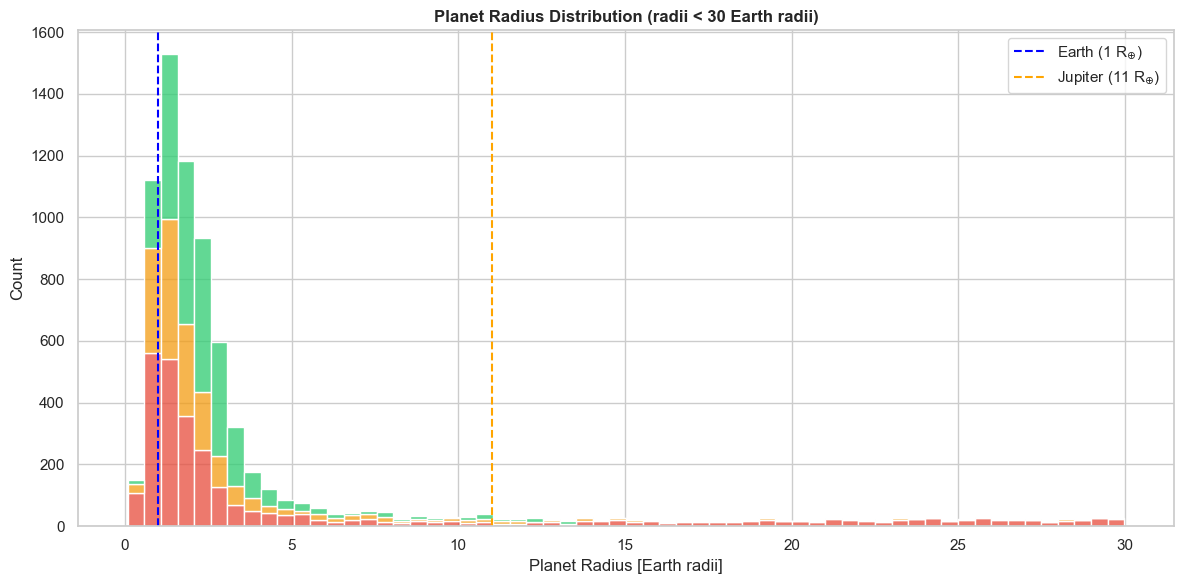

In [18]:
# Planet radius distribution by disposition
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=df_rel[df_rel['koi_prad'] < 30], x='koi_prad', hue='koi_disposition',
             palette=colors, bins=60, multiple='stack')
ax.set_title('Planet Radius Distribution (radii < 30 Earth radii)', fontweight='bold')
ax.set_xlabel('Planet Radius [Earth radii]')
ax.axvline(1, color='blue', linestyle='--', label='Earth (1 R$_{\\oplus}$)')
ax.axvline(11, color='orange', linestyle='--', label='Jupiter (11 R$_{\\oplus}$)')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Save the working DataFrame with relevant columns
output_file = DATA_INTERIM / "kepler_koi_relevant.csv"
df_rel.to_csv(output_file, index=False)
print(f"✓ Relevant subset saved to: {output_file}")
print(f"  File size: {output_file.stat().st_size / 1024:.1f} KB")
print(f"  Shape: {df_rel.shape[0]} rows × {df_rel.shape[1]} columns")

✓ Relevant subset saved to: c:\Users\diego.leon\Documents\proyectos\kepler-exoplanet-discovery-analysis\data\interim\kepler_koi_relevant.csv
  File size: 1040.3 KB
  Shape: 9564 rows × 19 columns


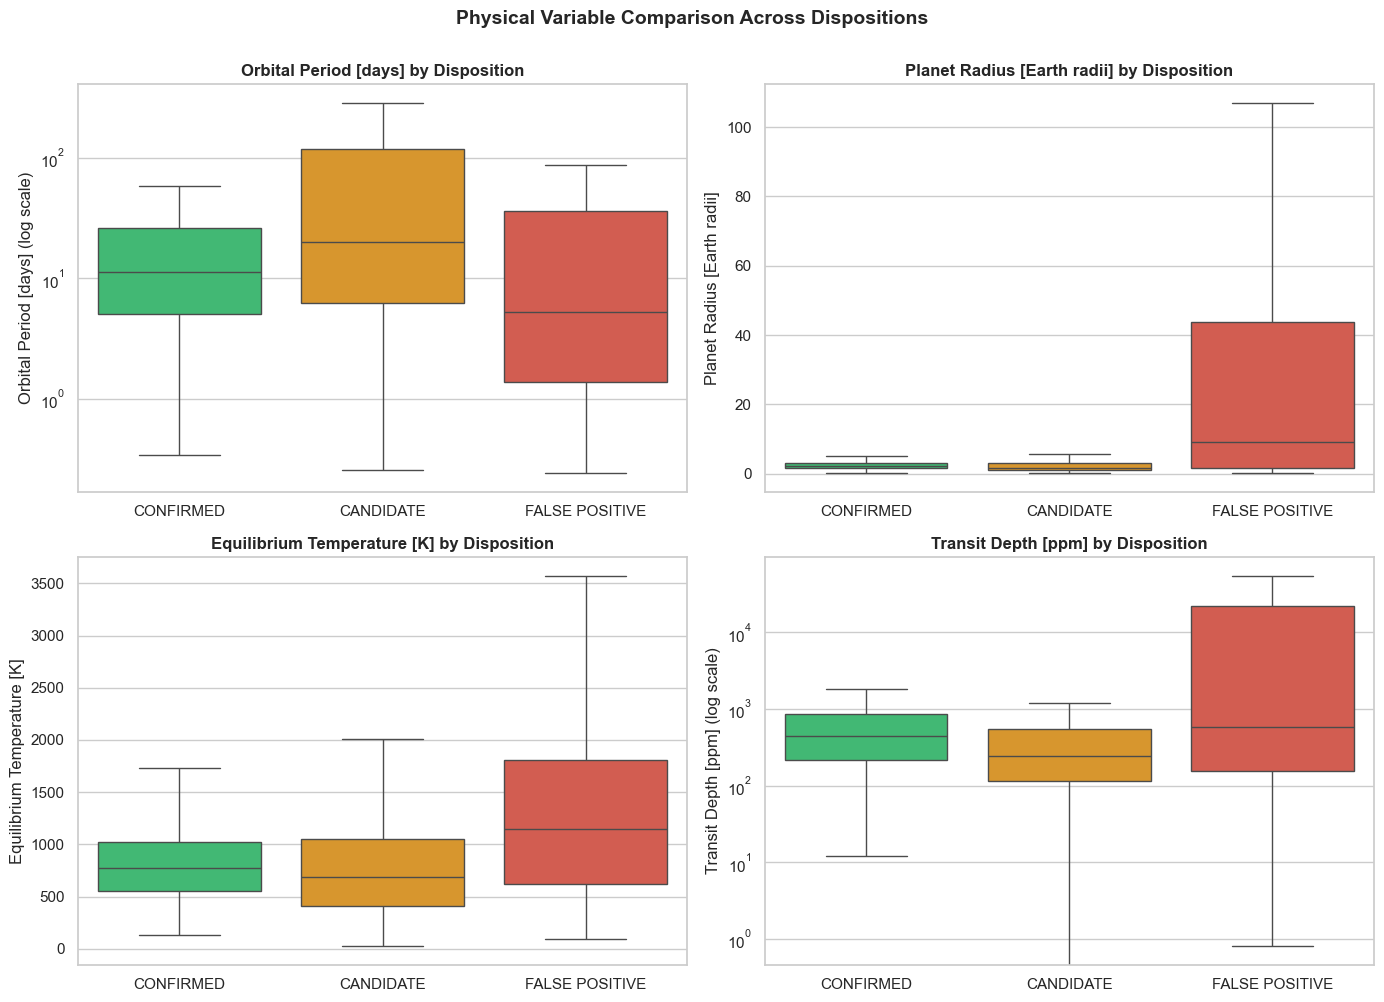

In [17]:
# Compare key physical variables across dispositions
key_features = ['koi_period', 'koi_prad', 'koi_teq', 'koi_depth']
feature_labels = {
    'koi_period': 'Orbital Period [days]',
    'koi_prad': 'Planet Radius [Earth radii]',
    'koi_teq': 'Equilibrium Temperature [K]',
    'koi_depth': 'Transit Depth [ppm]'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=df_rel, x='koi_disposition', y=feat,
            hue='koi_disposition', palette=colors, legend=False,
            ax=axes[i], showfliers=False,
            order=['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE'])
    axes[i].set_title(f'{feature_labels[feat]} by Disposition', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature_labels[feat])
    
    # Use log scale for period and depth (highly skewed)
    if feat in ['koi_period', 'koi_depth']:
        axes[i].set_yscale('log')
        axes[i].set_ylabel(f'{feature_labels[feat]} (log scale)')

plt.suptitle('Physical Variable Comparison Across Dispositions', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

False Positive Flags raised, by disposition:
koi_disposition   CANDIDATE  CONFIRMED  FALSE POSITIVE
Not transit-like          1        468            1526
Stellar eclipse           2         14            2210
Centroid offset           0          0            1889
Ephemeris match           0          0            1148


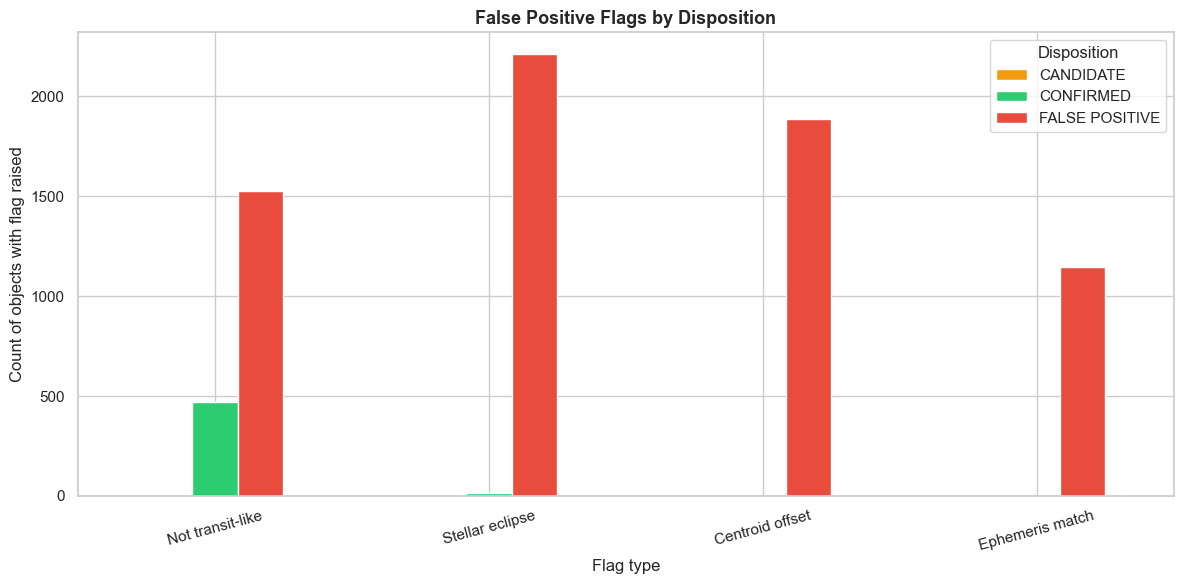

In [16]:
# Analysis of false positive flags
fp_flags = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']
fp_labels = {
    'koi_fpflag_nt': 'Not transit-like',
    'koi_fpflag_ss': 'Stellar eclipse',
    'koi_fpflag_co': 'Centroid offset',
    'koi_fpflag_ec': 'Ephemeris match'
}

# Count flags by disposition
flag_summary = df_rel.groupby('koi_disposition')[fp_flags].sum().T
flag_summary.index = [fp_labels[f] for f in flag_summary.index]

print("False Positive Flags raised, by disposition:")
print("=" * 60)
print(flag_summary)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
flag_summary.plot(kind='bar', ax=ax, color=[colors[c] for c in flag_summary.columns])
ax.set_title('False Positive Flags by Disposition', fontweight='bold', fontsize=13)
ax.set_xlabel('Flag type')
ax.set_ylabel('Count of objects with flag raised')
ax.legend(title='Disposition')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 📌 Conclusiones preliminares del EDA

### Estructura del dataset
- **9.564 objetos** en el catálogo Kepler.
- **155 columnas** en total, de las cuales **20 son relevantes** para análisis (físicas y de clasificación).

### Variable objetivo
- Distribución: **51% FALSE POSITIVE, 29% CONFIRMED, 21% CANDIDATE**.
- Las clases están razonablemente balanceadas (no hay extreme imbalance), lo que facilita el modelado.

### Valores faltantes
- `kepler_name` solo está disponible para exoplanetas confirmados (es esperado).
- Las variables físicas (período, radio, temperatura) tienen pocos NaN.

### Patrones observados
- **Periodo orbital:** distribución muy sesgada hacia valores cortos. Mejor visualizado en escala logarítmica.
- **Radio planetario:** la mayoría de los objetos son menores que Júpiter (11 R⊕). Hay una concentración importante en planetas tipo "súper-Tierra" (1-2 R⊕).

### Próximos pasos
- Análisis de correlación entre variables físicas.
- Comparación de variables clave entre `CONFIRMED` y `FALSE POSITIVE`.
- Tratamiento de valores faltantes y outliers.
- Preparación del dataset para modelado.